In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# Compare Normal (Fragile) vs Student-T (Robust) vs Ground Truth (Uncorrupted).
# We want to see how much one bad sensor/lab-error
# biases our engineering decisions and how studenT resists it.

TRUE_MU = 30.0
TRUE_SIGMA = 4.0
np.random.seed(42)


cube_tests = np.random.normal(loc=TRUE_MU, scale=TRUE_SIGMA, size=50)
cube_tests_corrupted = np.append(cube_tests, [5.0]) # The 'Black Swan' Outlier

# The Robust Model (Student-T on Corrupted Data)
with pm.Model() as robust_model:
    mu_robust = pm.Normal("mu_robust", mu=30, sigma=10)
    sigma_robust = pm.HalfNormal("sigma_robust", sigma=15)
    nu_robust = pm.Exponential("nu_robust", 1/30)
    pm.StudentT("y", nu=nu_robust, mu=mu_robust, sigma=sigma_robust, observed=cube_tests_corrupted)
    trace_robust = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=False)

# The Fragile Model (Normal on Corrupted Data)
with pm.Model() as fragile_model:
    mu_fragile = pm.Normal("mu_fragile", mu=30, sigma=10)
    sigma_fragile = pm.HalfNormal("sigma_fragile", sigma=15)
    pm.Normal("y", mu=mu_fragile, sigma=sigma_fragile, observed=cube_tests_corrupted)
    trace_fragile = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=False)

# The Baseline Model (Normal on CLEAN Data)
with pm.Model() as basic_model:
    mu_basic = pm.Normal("mu_basic", mu=30, sigma=10)
    sigma_basic = pm.HalfNormal("sigma_basic", sigma=15)
    pm.Normal("y", mu=mu_basic, sigma=sigma_basic, observed=cube_tests)
    trace_basic = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=False)

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

az.plot_posterior(trace_basic, var_names=["mu_basic"], ax=axes[0], ref_val=TRUE_MU)
axes[0].set_title("Ground Truth (n=50 Clean)")

az.plot_posterior(trace_fragile, var_names=["mu_fragile"], ax=axes[1], ref_val=TRUE_MU)
axes[1].set_title("Normal: Bias Shift (Fragile)")

az.plot_posterior(trace_robust, var_names=["mu_robust"], ax=axes[2], ref_val=TRUE_MU)
axes[2].set_title("Student-T: Outlier Resistant (Robust)")

plt.suptitle("Forensic Variation: Impact of Outliers vs Likelihood Choice", y=1.08)
plt.tight_layout()
plt.show()

# Forensic Quantification
mu_b = float(trace_basic.posterior["mu_basic"].mean())
mu_f = float(trace_fragile.posterior["mu_fragile"].mean())
mu_r = float(trace_robust.posterior["mu_robust"].mean())

print(f"--- Forensic Engineering Report ---")
print(f"True Site Mean:  {TRUE_MU:.2f} MPa")
print(f"Clean Posterior: {mu_b:.2f} MPa (System Target)")
print(f"Normal Shift:    {abs(mu_b - mu_f):.2f} MPa (Model Failure Risk)")
print(f"Robust Shift:    {abs(mu_b - mu_r):.2f} MPa (Robust Efficiency)")

### The normality parameter (nu)
    # nu controls "how Normal" the distribution is.
    # nu = infinity → exactly Normal. nu = 1 → extremely fat tails (Cauchy).
    # Exponential(1/30) is a standard weakly-informative prior for nu.

### INTERPRETATION: How to Read the Forest Plot
    # 1. THE DOT (Mean/Median): This is your "Point Estimate." 

    # 2. THE THICK CENTER LINE (50% HDI): Where half your belief mass sits.
    #    In engineering, if these thick lines don't overlap between models, the difference is significant.

    # 3. THE THIN HORIZONTAL WHISKERS (95% HDI): Your "Sovereign Risk Zone."
    #    If the 'mu_fragile' (Normal) whiskers are wider or shifted, you are looking at 'Precision Decay'.
    #    If 'sigma_fragile' whiskers grow larger than 'sigma_basic', the model is 'punished' by the outlier.

    # 4. OVERLAP = STABILITY: If the 'Robust (Student-T)' mu whiskers align perfectly 
    #    with the 'Ground Truth (Clean)' mu, the model successfully 'ignored' the forensic noise.


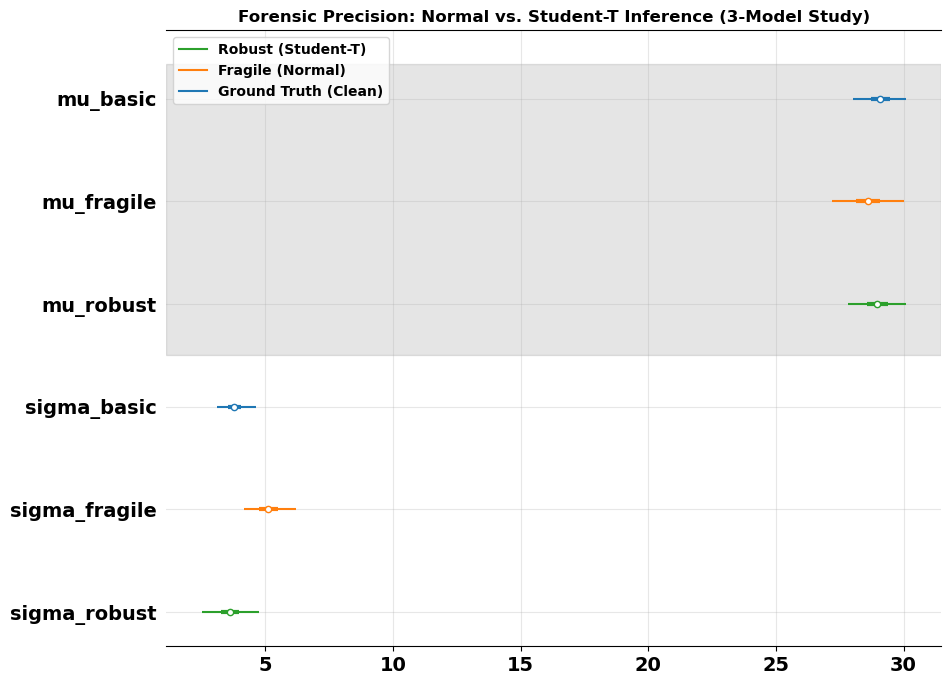

In [ ]:


# Interrogate the 'Precision Decay' and 'Bias Shift' in one view.
# var_names must be a flat list when passing multiple datasets.
# ArviZ will match the names found in each trace automatically.

fig, ax = plt.subplots(figsize=(10, 8))

az.plot_forest(
    [trace_basic, trace_fragile, trace_robust],
    model_names=["Ground Truth (Clean)", "Fragile (Normal)", "Robust (Student-T)"],
    var_names=["mu_basic", "mu_fragile", "mu_robust", "sigma_basic", "sigma_fragile", "sigma_robust"],
    combined=True,
    hdi_prob=0.95,
    ax=ax
)

plt.title("Forensic Precision: Normal vs. Student-T Inference (3-Model Study)")
plt.grid(True, alpha=0.3)
plt.show()

# Forensic Observation:
# Look at the 'mu' parameters:
#   1. 'mu_basic' (Clean) vs 'mu_fragile' (Dirty): The Fragile mean is pulled left.
#   2. 'mu_robust' (Dirty) vs 'mu_basic' (Clean): These dots should align horizontally.
# Look at the 'sigma' parameters:
#   3. 'sigma_fragile' (Dirty): This whisker will typically grow wider as the model tries
#      to explain the 'Black Swan' outlier with higher variability.


### To Student-T or not to Student-T?

**Question 1: Should I ALWAYS use Student-T?**
*No.* If you *always* use Student-T, you are building a model that structurally ignores extreme values. 
*   **The Danger:** What if the 5 MPa sample wasn't a "sensor error"? What if it was a real shear zone in the tunnel head? If you use Student-T, your model will "robust" that critical data point away, and the tunnel will collapse. 
*   **The Sovereign Rule:** Use `Normal` when you want the model to sound the alarm on *any* deviation. Use `Student-T` when you are modeling sensors/labs known to produce frequent "garbage" noise that you want the math to filter out automatically.

**Question 2: Why didn't we specify a mean for `HalfNormal`?**
*   A `pm.HalfNormal("sigma", sigma=15)` does not mean "a normal distribution shifted to the right." It is a normal distribution centered at `0`, folded over so no negative values exist.
*   The `sigma=15` in `HalfNormal` is *not* the expected value; it is the "scale" (how wide the prior is). 
*   The "dot" you see for `sigma` in the Forest Plot is the *Posterior* expected value of the concrete's variability, calculated by the MCMC engine based on the data. It is discovering the true $\sigma$ (around 4 MPa), overriding your broad prior.

**Question 3: Why did `sigma_fragile` shift to the right and get wider?**
*   **The Math:** The Normal likelihood assumes 100% of data points belong to the main distribution. When it sees `5 MPa` alongside `30 MPa`, it says: *"Wow, concrete is incredibly inconsistent!"* 
*   **The Result:** It artificially inflates its estimate of $\sigma$ (shifts the dot right) to stretch its bell curve wide enough to barely touch the 5 MPa data point.
*   **Why is the whisker so wide?** Because 50 points say "sigma is small" and 1 point says "sigma is massive." The model is conflicted, resulting in low precision (a wide whisker). 
*   **The Contrast:** The Student-T model (`sigma_robust`) assigns the 5 MPa point to its "fat tails," so it doesn't need to inflate its core $\sigma$ estimate. It agrees entirely with the Clean model.

### The "Buffer" and the HDI

1. **How the Normal Model "Buffers" (The Fragile Way)**
*   The Normal distribution *does not have fat tails*. It only has $\mu$ and $\sigma$. 
*   To cover the 5 MPa outlier without mathematically contradicting itself, it must literally stretch its entire body. It artificially inflates $\sigma$ (the standard deviation parameter). 
*   **Result on HDI:** Because $\sigma$ is forced to act as the buffer, the HDI for `sigma_fragile` explodes. The model becomes "confused" about the baseline variability, and precision collapses. 

2. **How the Student-T Model "Buffers" (The Robust Way)**
*   The Student-T distribution has a dedicated third parameter: $\nu$ (nu, degrees of freedom), which controls *tail thickness*.
*   When PyMC sees 50 points at 30 MPa and 1 point at 5 MPa, it mathematically routes that anomaly to $\nu$. It lowers the posterior estimate of $\nu$ (e.g., towards 1 or 2), which dramatically thickens the tails.
*   **The Math:** By lowering $\nu$, the model states: *"Extreme outlier events have a high, structural probability here."* Because $\nu$ takes 100% of the mathematical "blame" for the 5 MPa point, the likelihood calculation leaves your core variables ($\mu$ and $\sigma$) completely untouched.

3. **"Wouldn't buffering to tails affect our HDI?"**
*   **Absolutely. This is the Sovereign distinction between Parameter HDI and Predictive HDI.**
*   **Parameter HDI (The Forest Plot):** The HDI of `mu_robust` and `sigma_robust` stays extremely tight. Because $\nu$ absorbed the shock, the model remains highly confident about the *true center* ($\mu$) and *standard consistency* ($\sigma$) of the rock mass. The outlier did not corrupt your core engineering parameters.
*   **Predictive HDI (Future Concrete):** However, if you explicitly ask the PyMC model to simulate the *next* batch of concrete (`pm.sample_posterior_predictive`), that HDI will be massively wide. Why? Because the low $\nu$ parameter mathematically guarantees that future samples have a high probability of swinging into the fat tails (crashing down to 5 MPa).

**Contractual Reality:** 
*   **Normal Model:** Forces you to tell the client: *"I don't really know what the average concrete strength is anymore"* (Wide $\mu$ HDI). You appear incompetent because your core design parameters are ruined by one bad test.
*   **Student-T Model:** Allows you to tell the client: *"The average concrete strength is exactly 30 MPa with high precision (Tight $\mu$ HDI). However, my model mathematically proves ($\nu$) that this specific supplier occasionally delivers a 5 MPa completely failed batch."* (Fat tails in prediction). You decouple the **Systemic Baseline** from the **Catastrophic Outlier**.